# Kiểm tra và Khám phá Dữ liệu — RAG Soạn thảo Văn bản Hành chính

Notebook này kiểm tra và khám phá **3 bộ dữ liệu** chính của dự án:

| Dataset | File | Mô tả |
|---------|------|--------|
| `forms_dataset` | `forms_dataset.parquet` | 10 mẫu biểu (template) văn bản hành chính |
| `forms_examples_dataset` | `forms_examples_dataset.parquet` | 150 ví dụ văn bản đã điền sẵn (15 ví dụ/form) |
| `legal_dataset` | `legal_dataset.parquet` | ~515K bản ghi văn bản pháp luật thực tế |

**Mục tiêu:** Mô tả, khám phá, và kiểm tra tính đầy đủ/nhất quán của dữ liệu trước khi đưa vào pipeline.

> ⚠️ Notebook này **không** thực hiện tiền xử lý hay chunking — các bước đó sẽ ở phase sau.

---
## 0. Cài đặt và Import thư viện

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# --- Thiết lập hiển thị ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 20)

# --- Đường dẫn dataset ---
DATASET_DIR = Path("../dataset/raw")
PATHS = {
    "forms":          DATASET_DIR / "forms_dataset.parquet",
    "forms_examples": DATASET_DIR / "forms_examples_dataset.parquet",
    "legal":          DATASET_DIR / "legal_dataset.parquet",
}

print("✅ Import thành công.")
for name, path in PATHS.items():
    exists = "✅" if path.exists() else "❌ KHÔNG TÌM THẤY"
    print(f"  [{exists}] {name}: {path}")

✅ Import thành công.
  [✅] forms: ../dataset/raw/forms_dataset.parquet
  [✅] forms_examples: ../dataset/raw/forms_examples_dataset.parquet
  [✅] legal: ../dataset/raw/legal_dataset.parquet


---
## 1. Nạp dữ liệu

In [10]:
dfs = {}
for name, path in PATHS.items():
    try:
        dfs[name] = pd.read_parquet(path, engine="pyarrow")
        print(f"✅ {name}: {len(dfs[name]):,} bản ghi | {dfs[name].shape[1]} cột")
    except Exception as e:
        # Thử fallback engine
        try:
            dfs[name] = pd.read_parquet(path, engine="fastparquet")
            print(f"✅ {name} (fastparquet): {len(dfs[name]):,} bản ghi | {dfs[name].shape[1]} cột")
        except Exception as e2:
            print(f"❌ {name}: Lỗi — {e2}")

forms_df          = dfs.get("forms")
examples_df       = dfs.get("forms_examples")
legal_df          = dfs.get("legal")

✅ forms (fastparquet): 10 bản ghi | 5 cột
✅ forms_examples (fastparquet): 150 bản ghi | 88 cột
✅ legal (fastparquet): 515,188 bản ghi | 8 cột


In [11]:
#Print all columns of forms_df
print("\n📋 Cột của forms_df:"
      f"\n{forms_df.columns.tolist()}")


📋 Cột của forms_df:
['form_id', 'form_type', 'purpose', 'required_fields', 'template_markdown']


---
# PHẦN 1 — `forms_dataset`: Bộ mẫu biểu (10 templates)

## 1.1. Schema và tổng quan

In [12]:
print("=" * 60)
print("SCHEMA — forms_dataset")
print("=" * 60)
print(f"Kích thước: {forms_df.shape}")
print()
print("Kiểu dữ liệu từng cột:")
print(forms_df.dtypes)
print()
print("Giá trị thiếu:")
print(forms_df.isnull().sum())

SCHEMA — forms_dataset
Kích thước: (10, 5)

Kiểu dữ liệu từng cột:
form_id              object
form_type            object
purpose              object
required_fields      object
template_markdown    object
dtype: object

Giá trị thiếu:
form_id              0
form_type            0
purpose              0
required_fields      0
template_markdown    0
dtype: int64


## 1.2. Danh sách 10 biểu mẫu

In [13]:
print(f"Tổng số biểu mẫu: {len(forms_df)}")
print()

# Chuẩn hoá sang chuỗi — xử lý cả list thực, JSON string, numpy array
def fmt_type(v):
    if isinstance(v, list):
        return ", ".join(str(x) for x in v)
    if isinstance(v, str):
        import json
        stripped = v.strip()
        if stripped.startswith('['):
            try:
                parsed = json.loads(stripped)
                if isinstance(parsed, list):
                    return ", ".join(str(x) for x in parsed)
            except Exception:
                pass
        return stripped
    try:  # numpy array / other iterables
        return ", ".join(str(x) for x in v)
    except TypeError:
        return str(v)

display_df = forms_df[['form_id', 'form_type', 'purpose']].copy()
display_df['form_type'] = display_df['form_type'].apply(fmt_type)
print(display_df.to_markdown(index=False))

Tổng số biểu mẫu: 10

| form_id   | form_type                                                                                                                                                                          | purpose                                  |
|:----------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------|
| Form_10   | Giấy nghỉ phép                                                                                                                                                                     | Cấp phép nghỉ cho cán bộ                 |
| Form_01   | Nghị quyết                                                                                                                                                                         | Nghị quyết cá biệt                       |
| Form_02   | Quyết định  

## 1.3. Thống kê số lượng trường bắt buộc (required_fields)

In [14]:
# Debug: kiểm tra kiểu dữ liệu thực tế của required_fields
sample_val = forms_df['required_fields'].iloc[0]
print(f"Kiểu dữ liệu: {type(sample_val)}")
print(f"Giá trị mẫu : {repr(sample_val)[:300]}")

Kiểu dữ liệu: <class 'list'>
Giá trị mẫu : ['TEN_CQ_CHU_QUAN', 'TEN_CQ_CAP_PHEP', 'SO_GNP', 'CHU_VIET_TAT_CQ_CAP_PHEP', 'HO_TEN_NGUOI_NGHI', 'CHUC_VU', 'NGAY_BAT_DAU', 'NGAY_KET_THUC', 'NOI_NGHI_PHEP']


Số trường bắt buộc trung bình mỗi form: 12.4
Min: 9 | Max: 14

| form_id   | form_type                                                                                                                                                                          |   num_required_fields |
|:----------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------:|
| Form_10   | Giấy nghỉ phép                                                                                                                                                                     |                     9 |
| Form_01   | Nghị quyết                                                                                                                                                                         |                    12 |
| Form_02   | Quyết định                                     

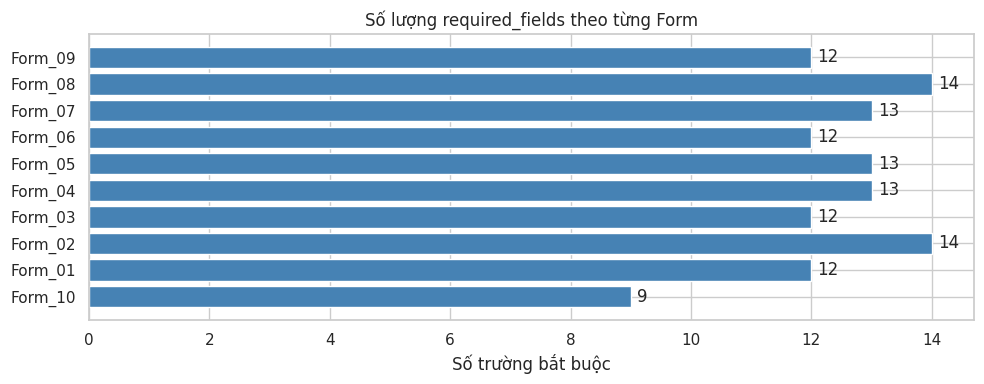

In [15]:
import json

def parse_list_field(val):
    """Chuyển đổi an toàn sang list — xử lý cả Python list, JSON string, numpy array."""
    if isinstance(val, list):
        return val
    # numpy array (pyarrow đôi khi trả về dạng này)
    try:
        import numpy as np
        if isinstance(val, np.ndarray):
            return val.tolist()
    except ImportError:
        pass
    if isinstance(val, str):
        stripped = val.strip()
        # JSON array string: '["a", "b"]'
        if stripped.startswith('['):
            try:
                parsed = json.loads(stripped)
                return parsed if isinstance(parsed, list) else []
            except (json.JSONDecodeError, ValueError):
                pass
        # Comma-separated string: 'a, b, c'
        return [s.strip() for s in stripped.split(',') if s.strip()]
    return []

forms_df['required_fields_parsed'] = forms_df['required_fields'].apply(parse_list_field)
forms_df['num_required_fields']    = forms_df['required_fields_parsed'].apply(len)

print(f"Số trường bắt buộc trung bình mỗi form: {forms_df['num_required_fields'].mean():.1f}")
print(f"Min: {forms_df['num_required_fields'].min()} | Max: {forms_df['num_required_fields'].max()}")
print()

stat_df = forms_df[['form_id', 'num_required_fields']].copy()
stat_df['form_type'] = forms_df['form_type'].apply(fmt_type)
print(stat_df[['form_id', 'form_type', 'num_required_fields']].to_markdown(index=False))

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(stat_df['form_id'], stat_df['num_required_fields'], color='steelblue')
ax.set_xlabel('Số trường bắt buộc')
ax.set_title('Số lượng required_fields theo từng Form')
for i, v in enumerate(stat_df['num_required_fields']):
    ax.text(v + 0.1, i, str(v), va='center')
plt.tight_layout()
plt.show()

## 1.4. Kiểm tra template — Placeholder coverage

In [16]:
import re

# Tên cột template trong forms_dataset là 'template_markdown'
TEMPLATE_COL = 'template_markdown' if 'template_markdown' in forms_df.columns else 'template'

def extract_placeholders(template_str):
    """Trích xuất tất cả {{FIELD}} từ template."""
    if not isinstance(template_str, str):
        return []
    return re.findall(r'\{\{([A-Z_]+)\}\}', template_str)

if TEMPLATE_COL in forms_df.columns:
    forms_df['placeholders_in_template'] = forms_df[TEMPLATE_COL].apply(extract_placeholders)
    forms_df['num_placeholders'] = forms_df['placeholders_in_template'].apply(len)

    # Placeholder nào trong template nhưng KHÔNG có trong required_fields
    def extra_placeholders(row):
        required   = set(row['required_fields_parsed'])  # đã parse ở cell 1.3
        in_tmpl    = set(row['placeholders_in_template'])
        extra      = in_tmpl - required
        missing    = required - in_tmpl
        return {'extra': sorted(extra), 'missing_from_tmpl': sorted(missing)}

    analysis = forms_df.apply(extra_placeholders, axis=1)
    forms_df['extra_in_template']    = analysis.apply(lambda x: x['extra'])
    forms_df['missing_from_template']= analysis.apply(lambda x: x['missing_from_tmpl'])

    print("Placeholder trong template vs required_fields:")
    check_df = forms_df[['form_id',
                          'num_required_fields',
                          'num_placeholders',
                          'extra_in_template',
                          'missing_from_template']].copy()
    print(check_df.to_markdown(index=False))
    print()

    # Tổng kết
    has_extra   = check_df['extra_in_template'].apply(len).gt(0).sum()
    has_missing = check_df['missing_from_template'].apply(len).gt(0).sum()
    if has_extra == 0 and has_missing == 0:
        print("✅ Template và required_fields khớp hoàn toàn — không có placeholder thừa/thiếu.")
    else:
        if has_extra:
            print(f"⚠️  {has_extra} form có placeholder trong template nhưng KHÔNG có trong required_fields (extra).")
        if has_missing:
            print(f"⚠️  {has_missing} form có required_fields nhưng KHÔNG xuất hiện trong template (missing).")
else:
    print(f"❌ Không tìm thấy cột template (đã thử: 'template_markdown', 'template').")
    print(f"   Các cột hiện có: {list(forms_df.columns)}")

Placeholder trong template vs required_fields:
| form_id   |   num_required_fields |   num_placeholders | extra_in_template                                                                                                                                                          | missing_from_template                   |
|:----------|----------------------:|-------------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------|
| Form_10   |                     9 |                 20 | ['CHE_DO_NGHI', 'DIA_DANH', 'DON_VI_SOAN_THAO', 'HO_TEN_NGUOI_LAM_DON', 'HO_VA_TEN_NGUOI_KY', 'NAM', 'NGAY', 'NGUOI_DUOC_CAP_PHEP', 'QUYEN_HAN_CHUC_VU_NGUOI_KY', 'THANG'] | []                                      |
| Form_01   |                    12 |                 15 | ['CHU_VIET_TAT_DON_VI_SOAN_THAO', 'CO_QUAN_NHAN_KHAC', 'QUYEN_HAN_CHUC_V

---
# PHẦN 2 — `forms_examples_dataset`: 150 ví dụ điền sẵn

## 2.1. Schema và tổng quan

In [17]:
print("=" * 60)
print("SCHEMA — forms_examples_dataset")
print("=" * 60)
print(f"Kích thước: {examples_df.shape}")
print()
print("Kiểu dữ liệu từng cột:")
print(examples_df.dtypes)
print()
print("5 dòng đầu tiên:")
display(examples_df.head())

SCHEMA — forms_examples_dataset
Kích thước: (150, 88)

Kiểu dữ liệu từng cột:
form_id                               object
form_type                             object
example_id                            object
scenario                              object
filled_content                        object
                                       ...  
fields.TRICH_YEU                      object
fields.TRICH_YEU_CONG_DIEN            object
fields.TRICH_YEU_CONG_VAN             object
fields.TRICH_YEU_NOI_DUNG             object
fields.TRICH_YEU_NOI_DUNG_CUOC_HOP    object
Length: 88, dtype: object

5 dòng đầu tiên:


,form_id,form_type,example_id,scenario,filled_content,doc_id,fields.CAC_VAN_DE_CAN_LUU_Y,fields.CAN_CU_PHAP_LY_1,fields.CAN_CU_PHAP_LY_2,fields.CHE_DO_NGHI,...,fields.THOI_GIAN_BAT_DAU,fields.THOI_GIAN_KET_THUC,fields.THU_DIEN_TU,fields.THU_KY,fields.TRANG_THONG_TIN_DIEN_TU,fields.TRICH_YEU,fields.TRICH_YEU_CONG_DIEN,fields.TRICH_YEU_CONG_VAN,fields.TRICH_YEU_NOI_DUNG,fields.TRICH_YEU_NOI_DUNG_CUOC_HOP
0,Form_01,Nghị quyết,Form_01_ex_001,HĐND tỉnh Quảng Ninh ban hành nghị quyết cá biệt phê duyệt chủ trương đầu tư...,HỘI ĐỒNG NHÂN DÂN TỈNH QUẢNG NINH \n**THƯỜNG TRỰC HỘI ĐỒNG NHÂN DÂN TỈNH QU...,Form_01_ex_001,None,"Luật Tổ chức chính quyền địa phương ngày 19 tháng 6 năm 2015; Luật sửa đổi, ...",Luật Đầu tư công ngày 13 tháng 6 năm 2019,None,...,None,None,None,None,None,None,None,None,"Về việc phê duyệt chủ trương đầu tư dự án cải tạo, nâng cấp tuyến đường liên...",None
1,Form_01,Nghị quyết,Form_01_ex_002,HĐND huyện Đức Trọng ban hành nghị quyết phê chuẩn quyết toán kinh phí sửa c...,HỘI ĐỒNG NHÂN DÂN HUYỆN ĐỨC TRỌNG \n**THƯỜNG TRỰC HỘI ĐỒNG NHÂN DÂN HUYỆN Đ...,Form_01_ex_002,None,Luật Ngân sách nhà nước ngày 25 tháng 6 năm 2015,"Luật Tổ chức chính quyền địa phương ngày 19 tháng 6 năm 2015; Luật sửa đổi, ...",None,...,None,None,None,None,None,None,None,None,Về việc phê chuẩn quyết toán kinh phí sửa chữa khối phòng học Trường Tiểu họ...,None
2,Form_01,Nghị quyết,Form_01_ex_003,HĐND xã Tân Phú Đông ban hành nghị quyết về việc điều chỉnh tên tuyến đường ...,HỘI ĐỒNG NHÂN DÂN XÃ TÂN PHÚ ĐÔNG \n**THƯỜNG TRỰC HỘI ĐỒNG NHÂN DÂN XÃ TÂN ...,Form_01_ex_003,None,Luật Đất đai ngày 29 tháng 11 năm 2013,Luật Tổ chức chính quyền địa phương ngày 19 tháng 6 năm 2015,None,...,None,None,None,None,None,None,None,None,Về việc thống nhất điều chỉnh tên tuyến đường nội đồng khu vực ấp Tân Hòa để...,None
3,Form_01,Nghị quyết,Form_01_ex_004,HĐND tỉnh Thừa Thiên Huế ban hành nghị quyết cá biệt về việc đặt tên công vi...,HỘI ĐỒNG NHÂN DÂN TỈNH THỪA THIÊN HUẾ \n**THƯỜNG TRỰC HỘI ĐỒNG NHÂN DÂN TỈN...,Form_01_ex_004,None,"Luật Tổ chức chính quyền địa phương ngày 19 tháng 6 năm 2015; Luật sửa đổi, ...",Nghị định số 91/2005/NĐ-CP ngày 11 tháng 7 năm 2005 của Chính phủ ban hành Q...,None,...,None,None,None,None,None,None,None,None,Về việc đặt tên công viên công cộng ven sông Hương đoạn từ cầu Dã Viên đến c...,None
4,Form_01,Nghị quyết,Form_01_ex_005,HĐND huyện Yên Thành ban hành nghị quyết chấp thuận điều chỉnh quy mô chợ nô...,HỘI ĐỒNG NHÂN DÂN HUYỆN YÊN THÀNH \n**THƯỜNG TRỰC HỘI ĐỒNG NHÂN DÂN HUYỆN Y...,Form_01_ex_005,None,"Luật Xây dựng ngày 18 tháng 6 năm 2014; Luật sửa đổi, bổ sung một số điều củ...",Luật Đầu tư công ngày 13 tháng 6 năm 2019,None,...,None,None,None,None,None,None,None,None,Về việc chấp thuận điều chỉnh quy mô đầu tư xây dựng chợ nông thôn xã Bảo Thành,None


## 2.2. Phân bố theo form_type và form_id

Phân bố theo form_id:
| form_id   |   Số ví dụ |
|:----------|-----------:|
| Form_01   |         15 |
| Form_02   |         15 |
| Form_03   |         15 |
| Form_04   |         15 |
| Form_05   |         15 |
| Form_06   |         15 |
| Form_07   |         15 |
| Form_08   |         15 |
| Form_09   |         15 |
| Form_10   |         15 |

Phân bố theo form_type (top 20):
| form_type       |   Số ví dụ |
|:----------------|-----------:|
| Quyết định      |         30 |
| Nghị quyết      |         15 |
| Công văn        |         15 |
| Công điện       |         15 |
| Giấy mời        |         15 |
| Giấy giới thiệu |         15 |
| Biên bản        |         15 |
| Giấy nghỉ phép  |         15 |
| Thông báo       |          2 |
| Báo cáo         |          2 |
| Kế hoạch        |          1 |
| Tờ trình        |          1 |
| Hướng dẫn       |          1 |
| Chỉ thị         |          1 |
| Chương trình    |          1 |
| Thông cáo       |          1 |
| Đề án           |       

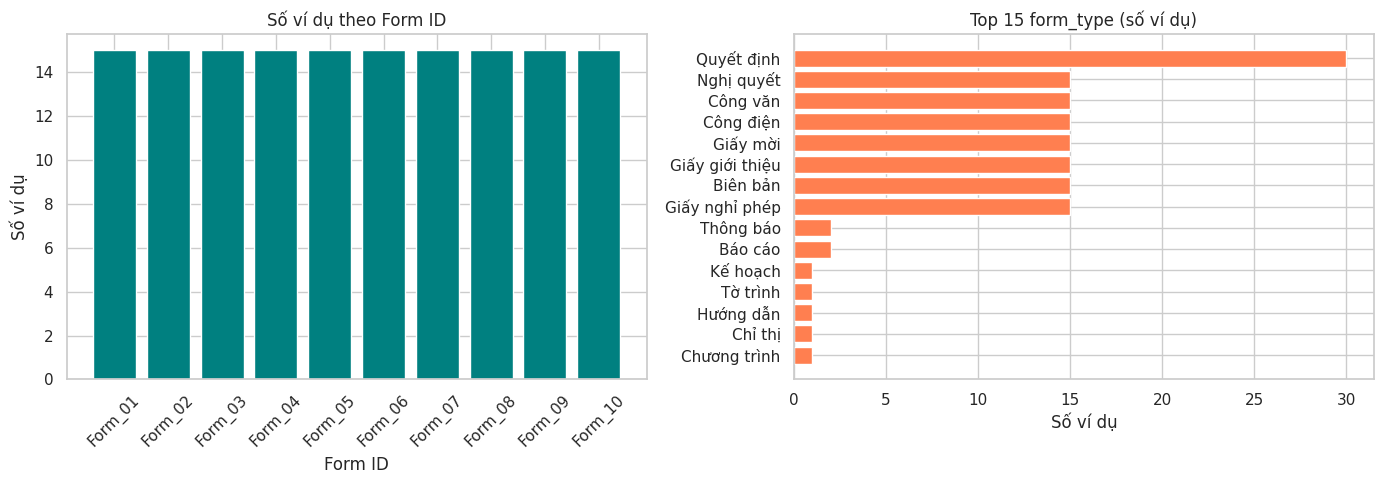

In [18]:
print("Phân bố theo form_id:")
form_id_counts = examples_df['form_id'].value_counts().sort_index()
print(form_id_counts.to_frame('Số ví dụ').to_markdown())
print()

print("Phân bố theo form_type (top 20):")
type_counts = examples_df['form_type'].value_counts()
print(type_counts.head(20).to_frame('Số ví dụ').to_markdown())

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cột trái: theo form_id
axes[0].bar(form_id_counts.index, form_id_counts.values, color='teal')
axes[0].set_title('Số ví dụ theo Form ID')
axes[0].set_xlabel('Form ID')
axes[0].set_ylabel('Số ví dụ')
axes[0].tick_params(axis='x', rotation=45)

# Cột phải: theo form_type (top 15)
top_types = type_counts.head(15)
axes[1].barh(top_types.index[::-1], top_types.values[::-1], color='coral')
axes[1].set_title('Top 15 form_type (số ví dụ)')
axes[1].set_xlabel('Số ví dụ')

plt.tight_layout()
plt.show()

## 2.3. Kiểm tra chất lượng — Giá trị thiếu & Placeholder chưa điền

In [19]:
# --- Missing values ---
print("--- MISSING VALUES ---")
missing = examples_df.isnull().sum()
pct = (missing / len(examples_df) * 100).round(2)
miss_report = pd.DataFrame({'Số thiếu': missing, 'Tỷ lệ (%)': pct})
has_missing = miss_report[miss_report['Số thiếu'] > 0]
if len(has_missing) == 0:
    print("✅ Không có giá trị thiếu.")
else:
    print(has_missing.to_markdown())
print()

# --- Placeholder chưa điền trong filled_content ---
print("--- KIỂM TRA PLACEHOLDER CHƯA ĐIỀN trong 'filled_content' ---")
if 'filled_content' in examples_df.columns:
    def find_remaining(text):
        if not isinstance(text, str):
            return []
        return re.findall(r'\{\{[A-Z_]+\}\}', text)

    examples_df['remaining_placeholders'] = examples_df['filled_content'].apply(find_remaining)
    bad = examples_df[examples_df['remaining_placeholders'].apply(len) > 0]

    if len(bad) == 0:
        print(f"✅ Tất cả {len(examples_df)} ví dụ đã được điền đầy đủ — không còn placeholder.")
    else:
        print(f"⚠️  {len(bad)} ví dụ còn placeholder chưa điền:")
        print(bad[['example_id', 'form_type', 'remaining_placeholders']].to_markdown(index=False))
else:
    print("ℹ️  Không tìm thấy cột 'filled_content'.")

--- MISSING VALUES ---
|                                             |   Số thiếu |   Tỷ lệ (%) |
|:--------------------------------------------|-----------:|------------:|
| fields.CAC_VAN_DE_CAN_LUU_Y                 |        135 |          90 |
| fields.CAN_CU_PHAP_LY_1                     |        105 |          70 |
| fields.CAN_CU_PHAP_LY_2                     |        105 |          70 |
| fields.CHE_DO_NGHI                          |        135 |          90 |
| fields.CHUC_VU                              |        120 |          80 |
| fields.CHU_VIET_TAT_CQ_BAN_HANH             |         15 |          10 |
| fields.CHU_VIET_TAT_CQ_CAP_PHEP             |        135 |          90 |
| fields.CHU_VIET_TAT_DON_VI_SOAN_THAO        |         45 |          30 |
| fields.CHU_VIET_TAT_LOAI_VB                 |        135 |          90 |
| fields.CO_QUAN_CA_NHAN_NHAN_1               |        135 |          90 |
| fields.CO_QUAN_CA_NHAN_NHAN_2               |        135 |          90 |
| 

## 2.4. Kiểm tra doc_id duy nhất

In [20]:
id_col = 'doc_id' if 'doc_id' in examples_df.columns else 'example_id'
total = len(examples_df)
unique = examples_df[id_col].nunique()
dup = total - unique

print(f"Cột ID dùng để kiểm tra: '{id_col}'")
print(f"Tổng bản ghi : {total}")
print(f"ID duy nhất  : {unique}")
print(f"ID trùng lặp : {dup}")

if dup == 0:
    print("✅ Không có ID trùng lặp.")
else:
    print("⚠️  Danh sách ID trùng:")
    print(examples_df[examples_df[id_col].duplicated(keep=False)][id_col].value_counts())

Cột ID dùng để kiểm tra: 'doc_id'
Tổng bản ghi : 150
ID duy nhất  : 150
ID trùng lặp : 0
✅ Không có ID trùng lặp.


## 2.5. Phân bố độ dài văn bản đã điền (filled_content)

Thống kê độ dài filled_content (số từ):
count    150.0
mean     278.5
std       92.4
min      133.0
25%      217.5
50%      280.0
75%      329.8
max      473.0
Name: word_count, dtype: float64

Thống kê theo form_id (trung bình số từ):
| form_id   |   word_count |
|:----------|-------------:|
| Form_01   |        326.2 |
| Form_02   |        292.7 |
| Form_03   |        297.6 |
| Form_04   |        258.6 |
| Form_05   |        390.1 |
| Form_06   |        273.2 |
| Form_07   |        220.5 |
| Form_08   |        145.4 |
| Form_09   |        439.3 |
| Form_10   |        141.1 |


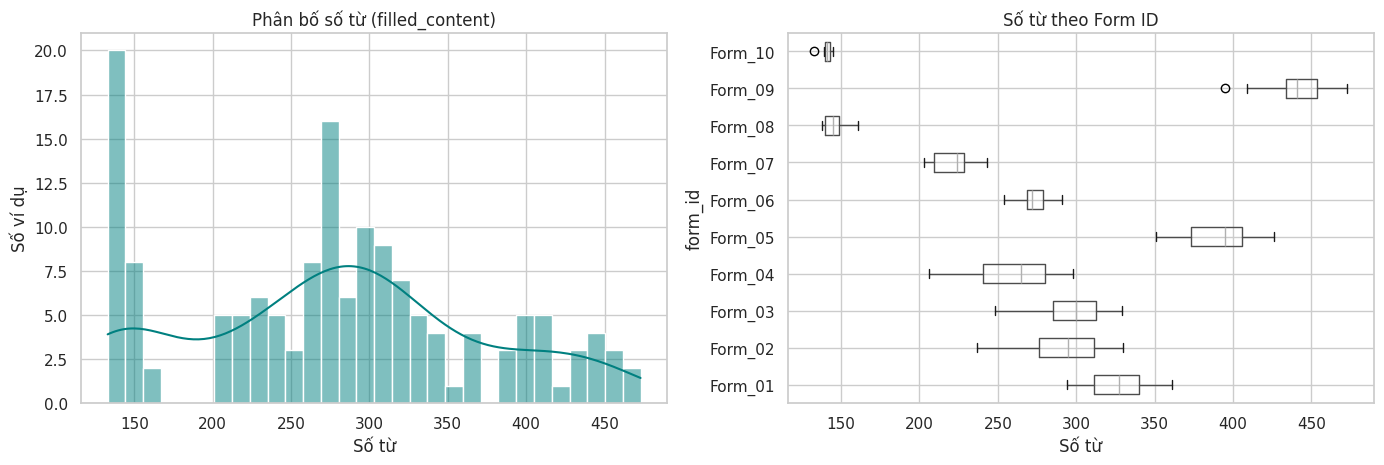

In [21]:
if 'filled_content' in examples_df.columns:
    examples_df['word_count'] = examples_df['filled_content'].fillna('').apply(
        lambda x: len(x.split())
    )
    examples_df['char_count'] = examples_df['filled_content'].fillna('').apply(len)

    print("Thống kê độ dài filled_content (số từ):")
    print(examples_df['word_count'].describe().round(1))
    print()
    print("Thống kê theo form_id (trung bình số từ):")
    print(examples_df.groupby('form_id')['word_count'].mean().round(1).to_frame().to_markdown())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(examples_df['word_count'], bins=30, kde=True, ax=axes[0], color='teal')
    axes[0].set_title('Phân bố số từ (filled_content)')
    axes[0].set_xlabel('Số từ')
    axes[0].set_ylabel('Số ví dụ')

    examples_df.boxplot(column='word_count', by='form_id', ax=axes[1], vert=False)
    axes[1].set_title('Số từ theo Form ID')
    axes[1].set_xlabel('Số từ')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  Không tìm thấy cột 'filled_content'.")

## 2.6. Thống kê số lượng trường được điền (fields dict)

In [22]:
if 'fields' in examples_df.columns:
    examples_df['num_fields_filled'] = examples_df['fields'].apply(
        lambda x: len(x) if isinstance(x, dict) else 0
    )
    print("Thống kê số field được điền mỗi ví dụ:")
    print(examples_df['num_fields_filled'].describe().round(1))
    print()

    # Kiểm tra có ví dụ nào bị điền ít field bất thường không
    min_fields = examples_df['num_fields_filled'].min()
    if min_fields < 5:
        sparse = examples_df[examples_df['num_fields_filled'] < 5]
        print(f"⚠️  {len(sparse)} ví dụ có ít hơn 5 fields được điền:")
        print(sparse[['example_id', 'form_type', 'num_fields_filled']].to_markdown(index=False))
    else:
        print(f"✅ Tất cả ví dụ có ít nhất {min_fields} fields được điền.")
else:
    print("ℹ️  Không tìm thấy cột 'fields'.")

ℹ️  Không tìm thấy cột 'fields'.


---
# PHẦN 3 — `legal_dataset`: Văn bản pháp luật (~515K bản ghi)

## 3.1. Schema và tổng quan

In [23]:
print("=" * 60)
print("SCHEMA — legal_dataset")
print("=" * 60)
print(f"Kích thước: {legal_df.shape}  ({len(legal_df):,} bản ghi)")
print()
print("Kiểu dữ liệu từng cột:")
print(legal_df.dtypes)
print()
print("1 bản ghi mẫu (iloc[0]):")
print(legal_df.iloc[0].to_string())

SCHEMA — legal_dataset
Kích thước: (515188, 8)  (515,188 bản ghi)

Kiểu dữ liệu từng cột:
id              object
ministry        object
type            object
name            object
chapter_id      object
chapter_name    object
article         object
content         object
dtype: object

1 bản ghi mẫu (iloc[0]):
id                                                                   01/2014/NQLT/CP-UBTƯMTTQVN
ministry                                CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM
type                                                                       NGHỊ QUYẾT LIÊN TỊCH
name             HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ
chapter_id                                                                             Chương I
chapter_name                                                               NHỮNG QUY ĐỊNH CHUNG
article                                                              Điều 1. Phạm vi điều chỉnh
content       

In [24]:
display(legal_df.head())

,id,ministry,type,name,chapter_id,chapter_name,article,content
0,01/2014/NQLT/CP-UBTƯMTTQVN,CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM,NGHỊ QUYẾT LIÊN TỊCH,HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ,Chương I,NHỮNG QUY ĐỊNH CHUNG,Điều 1. Phạm vi điều chỉnh,Nghị quyết liên tịch này hướng dẫn phối hợp thực hiện một số quy định của ph...
1,01/2014/NQLT/CP-UBTƯMTTQVN,CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM,NGHỊ QUYẾT LIÊN TỊCH,HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ,Chương I,NHỮNG QUY ĐỊNH CHUNG,Điều 2. Nguyên tắc phối hợp,"1. Việc phối hợp hoạt động được thực hiện trên cơ sở chức năng, nhiệm vụ, qu..."
2,01/2014/NQLT/CP-UBTƯMTTQVN,CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM,NGHỊ QUYẾT LIÊN TỊCH,HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ,Chương II,PHỐI HỢP THỰC HIỆN QUẢN LÝ NHÀ NƯỚC VỀ HÒA GIẢI Ở CƠ SỞ,Điều 3. Hướng dẫn và tổ chức thực hiện các quy định của pháp luật về hòa giả...,"Ủy ban Trung ương Mặt trận Tổ quốc Việt Nam, Ủy ban Mặt trận Tổ quốc Việt Na..."
3,01/2014/NQLT/CP-UBTƯMTTQVN,CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM,NGHỊ QUYẾT LIÊN TỊCH,HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ,Chương II,PHỐI HỢP THỰC HIỆN QUẢN LÝ NHÀ NƯỚC VỀ HÒA GIẢI Ở CƠ SỞ,"Điều 4. Tổ chức phổ biến, vận động nhân dân thực hiện pháp luật về hòa giải ...","1. Ủy ban Mặt trận Tổ quốc Việt Nam, các tổ chức thành viên của Mặt trận các..."
4,01/2014/NQLT/CP-UBTƯMTTQVN,CHÍNH PHỦ - ỦY BAN TRUNG ƯƠNG MẶT TRẬN TỔ QUỐC VIỆT NAM,NGHỊ QUYẾT LIÊN TỊCH,HƯỚNG DẪN PHỐI HỢP THỰC HIỆN MỘT SỐ QUY ĐỊNH CỦA PHÁP LUẬT VỀ HÒA GIẢI Ở CƠ SỞ,Chương II,PHỐI HỢP THỰC HIỆN QUẢN LÝ NHÀ NƯỚC VỀ HÒA GIẢI Ở CƠ SỞ,Điều 5. Kiểm tra việc thực hiện pháp luật về hòa giải ở cơ sở,"1. Ủy ban Trung ương Mặt trận Tổ quốc Việt Nam, Ủy ban Mặt trận Tổ quốc Việt..."


## 3.2. Kiểm tra Giá trị Thiếu (Missing Values)

--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---
|            |   Số lượng thiếu |   Tỷ lệ (%) |
|:-----------|-----------------:|------------:|
| content    |            90706 |       17.61 |
| ministry   |              757 |        0.15 |
| id         |              350 |        0.07 |
| article    |              309 |        0.06 |
| type       |               35 |        0.01 |
| name       |               16 |        0    |
| chapter_id |                3 |        0    |

Tổng số bản ghi: 515,188
Content rỗng (empty string, không phải NaN): 90,706 (17.61%)


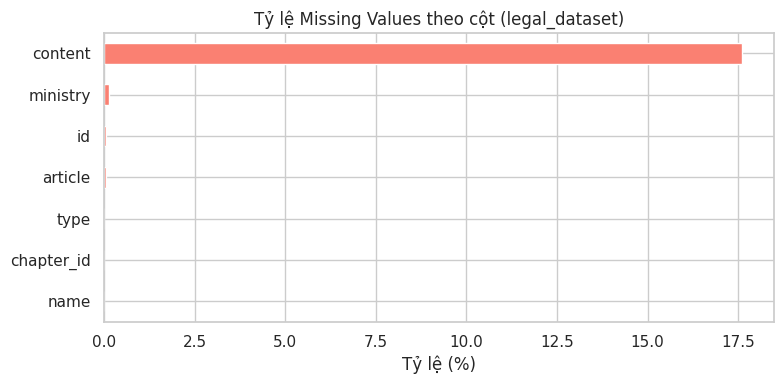

In [25]:
print("--- KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES) ---")
missing_data = legal_df.isnull().sum()
missing_pct  = (missing_data / len(legal_df) * 100).round(2)

missing_report = pd.DataFrame({
    'Số lượng thiếu': missing_data,
    'Tỷ lệ (%)': missing_pct
}).sort_values('Tỷ lệ (%)', ascending=False)

has_missing = missing_report[missing_report['Số lượng thiếu'] > 0]
if len(has_missing) == 0:
    print("✅ Không có giá trị thiếu.")
else:
    print(has_missing.to_markdown())

print(f"\nTổng số bản ghi: {len(legal_df):,}")

# Kiểm tra content rỗng (empty string nhưng không phải NaN)
if 'content' in legal_df.columns:
    empty_content = legal_df['content'].fillna('').str.strip().eq('').sum()
    pct_empty = empty_content / len(legal_df) * 100
    print(f"Content rỗng (empty string, không phải NaN): {empty_content:,} ({pct_empty:.2f}%)")

# Trực quan hoá
if len(has_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    has_missing['Tỷ lệ (%)'].sort_values().plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Tỷ lệ Missing Values theo cột (legal_dataset)')
    ax.set_xlabel('Tỷ lệ (%)')
    plt.tight_layout()
    plt.show()

## 3.3. Phân bố Loại văn bản (type)

TOP 15 LOẠI VĂN BẢN PHỔ BIẾN:
| type                 |   Số bản ghi |
|:---------------------|-------------:|
| THÔNG TƯ             |       147670 |
| QUYẾT ĐỊNH           |       130574 |
| NGHỊ QUYẾT           |        90768 |
| NGHỊ ĐỊNH            |        82882 |
| LUẬT                 |        32609 |
| QUYẾT                |         8041 |
| ĐỊNH                 |              |
| none                 |         6660 |
| NGHỊ                 |         5405 |
| QUYẾT                |              |
| PHÁP LỆNH            |         4401 |
| PHÁP LỆNH            |         1165 |
| ORDINANCE            |          570 |
| PHÁP                 |          493 |
| LỆNH                 |              |
| LỆNH                 |          485 |
| NGHỊ QUYẾT LIÊN TỊCH |          400 |
| QUYẾT NGHỊ:          |          346 |

Tổng số loại văn bản duy nhất (bao gồm cả các giá trị nhiễu): 98


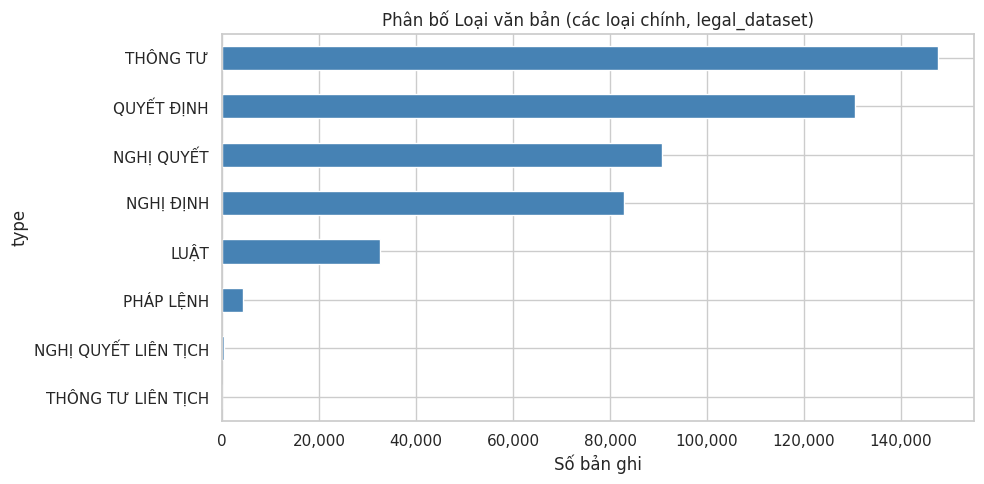

In [26]:
print("TOP 15 LOẠI VĂN BẢN PHỔ BIẾN:")
type_counts = legal_df['type'].value_counts()
top_types = type_counts.head(15)
print(top_types.to_frame('Số bản ghi').to_markdown())
print(f"\nTổng số loại văn bản duy nhất (bao gồm cả các giá trị nhiễu): {legal_df['type'].nunique()}")

# Lọc chỉ giữ các loại 'sạch' phổ biến để vẽ biểu đồ
clean_types = [
    'THÔNG TƯ', 'QUYẾT ĐỊNH', 'NGHỊ QUYẾT', 'NGHỊ ĐỊNH', 'LUẬT',
    'PHÁP LỆNH', 'THÔNG TƯ LIÊN TỊCH', 'NGHỊ QUYẾT LIÊN TỊCH'
]
clean_counts = type_counts[type_counts.index.isin(clean_types)]

fig, ax = plt.subplots(figsize=(10, 5))
clean_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Phân bố Loại văn bản (các loại chính, legal_dataset)')
ax.set_xlabel('Số bản ghi')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 3.4. Phân bố Cơ quan ban hành (ministry)

TOP 15 CƠ QUAN BAN HÀNH NHIỀU NHẤT:
| ministry                               |   Số bản ghi |
|:---------------------------------------|-------------:|
| CHÍNH PHỦ                              |        85021 |
| QUỐC HỘI                               |        32538 |
| BỘ TÀI CHÍNH                           |        27455 |
| BỘ GIAO THÔNG VẬN TẢI                  |        14169 |
| BỘ CÔNG THƯƠNG                         |        11106 |
| BỘ Y TẾ                                |         9459 |
| BỘ NÔNG NGHIỆP VÀ PHÁT TRIỂN NÔNG THÔN |         9382 |
| BỘ TÀI NGUYÊN VÀ MÔI TRƯỜNG            |         9317 |
| BỘ GIÁO DỤC VÀ ĐÀO TẠO                 |         9102 |
| NGÂN HÀNG NHÀ NƯỚC VIỆT NAM            |         7402 |
| BỘ LAO ĐỘNG - THƯƠNG BINH VÀ XÃ HỘI    |         7212 |
| BỘ QUỐC PHÒNG                          |         6828 |
| BỘ THÔNG TIN VÀ TRUYỀN THÔNG           |         6587 |
| THỦ TƯỚNG CHÍNH PHỦ                    |         5824 |
| BỘ KHOA HỌC VÀ CÔNG NGHỆ          

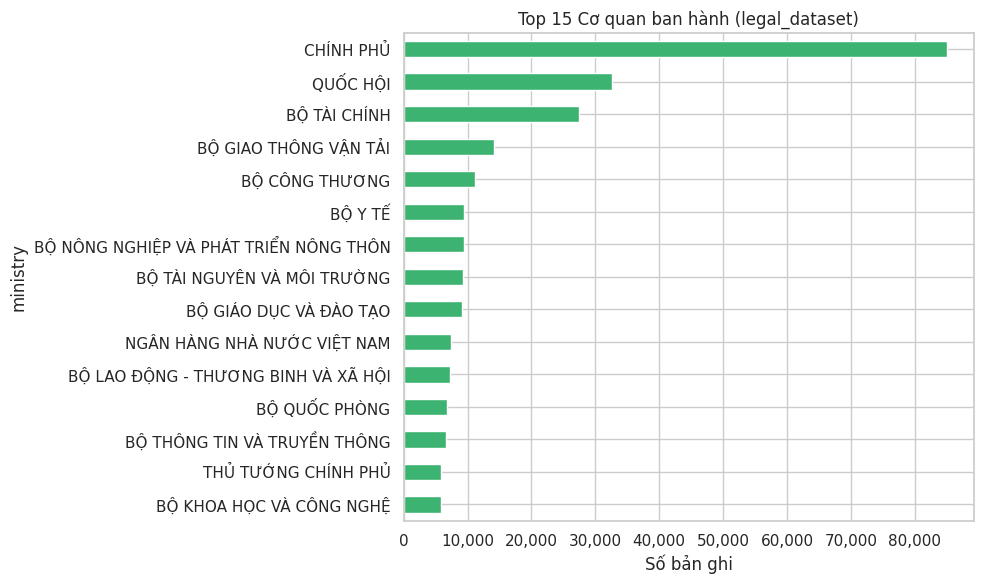

In [27]:
print("TOP 15 CƠ QUAN BAN HÀNH NHIỀU NHẤT:")
ministry_counts = legal_df['ministry'].value_counts()
print(ministry_counts.head(15).to_frame('Số bản ghi').to_markdown())

fig, ax = plt.subplots(figsize=(10, 6))
ministry_counts.head(15).sort_values().plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Top 15 Cơ quan ban hành (legal_dataset)')
ax.set_xlabel('Số bản ghi')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 3.5. Báo cáo độ phủ — Các văn bản pháp lý cốt lõi cho RAG soạn thảo

In [28]:
# Danh sách văn bản "sống còn" cho RAG soạn thảo hành chính
important_laws = {
    "Nghị định 30/2020/NĐ-CP (Công tác văn thư)": r"30/2020/NĐ-CP",
    "Bộ luật Lao động 2019": r"45/2019/QH14|Lao động 2019",
    "Luật Cán bộ, Công chức": r"Luật Cán bộ, công chức",
    "Luật Viên chức": r"Luật Viên chức",
    "Luật Ban hành văn bản QPPL": r"80/2015/QH13|15/2020/QH14",
    "Luật Lưu trữ": r"01/2011/QH13",
    "Luật Tổ chức Chính phủ": r"Luật Tổ chức Chính phủ",
    "Luật Tổ chức Chính quyền địa phương": r"Luật Tổ chức chính quyền địa phương",
}

results = []
for label, pattern in important_laws.items():
    mask = (
        legal_df['id'].str.contains(pattern, case=False, na=False) |
        legal_df['name'].str.contains(pattern, case=False, na=False)
    )
    count = mask.sum()
    status = "✅ CÓ" if count > 0 else "❌ THIẾU"
    results.append({'Văn bản pháp lý': label, 'Trạng thái': status, 'Số dòng (Articles)': count})

coverage_df = pd.DataFrame(results)
print("=" * 60)
print("BÁO CÁO ĐỘ PHỦ VĂN BẢN PHÁP LÝ QUAN TRỌNG")
print("=" * 60)
print(coverage_df.to_string(index=False))
print("=" * 60)

missing_laws = coverage_df[coverage_df['Trạng thái'] == '❌ THIẾU']
if len(missing_laws) == 0:
    print("\n✅ Tất cả văn bản cốt lõi đều có mặt trong dataset.")
else:
    print(f"\n⚠️  {len(missing_laws)} văn bản quan trọng còn thiếu — cần bổ sung.")

BÁO CÁO ĐỘ PHỦ VĂN BẢN PHÁP LÝ QUAN TRỌNG
                           Văn bản pháp lý Trạng thái  Số dòng (Articles)
Nghị định 30/2020/NĐ-CP (Công tác văn thư)       ✅ CÓ                  63
                     Bộ luật Lao động 2019       ✅ CÓ                 220
                    Luật Cán bộ, Công chức       ✅ CÓ                 164
                            Luật Viên chức       ✅ CÓ                  48
                Luật Ban hành văn bản QPPL       ✅ CÓ                 180
                              Luật Lưu trữ       ✅ CÓ                  42
                    Luật Tổ chức Chính phủ       ✅ CÓ                   4
       Luật Tổ chức Chính quyền địa phương       ✅ CÓ                   4

✅ Tất cả văn bản cốt lõi đều có mặt trong dataset.


## 3.6. Kiểm tra Trùng lặp (Duplication)

In [29]:
print("--- KIỂM TRA ĐỘ TRÙNG LẶP ---")

# Trùng lặp toàn bộ hàng
exact_dup = legal_df.duplicated().sum()
print(f"Dòng trùng hoàn toàn: {exact_dup:,} ({exact_dup/len(legal_df)*100:.2f}%)")

# Trùng lặp theo content
if 'content' in legal_df.columns:
    content_dup = legal_df.dropna(subset=['content']).duplicated(subset=['content']).sum()
    print(f"Dòng có content trùng: {content_dup:,} ({content_dup/len(legal_df)*100:.2f}%)")

# Trùng lặp theo id
if 'id' in legal_df.columns:
    id_dup = legal_df.dropna(subset=['id']).duplicated(subset=['id']).sum()
    print(f"Dòng có id trùng: {id_dup:,} ({id_dup/len(legal_df)*100:.2f}%)")

# Trùng lặp theo (id + article) — unit chunk
if 'id' in legal_df.columns and 'article' in legal_df.columns:
    chunk_dup = legal_df.dropna(subset=['id', 'article']).duplicated(subset=['id', 'article']).sum()
    print(f"Dòng có (id, article) trùng: {chunk_dup:,} ({chunk_dup/len(legal_df)*100:.2f}%)")

print()
if exact_dup > 0 or content_dup > 0:
    print("⚠️  Phát hiện trùng lặp — nên de-duplicate trước khi xây dựng Vector DB.")
else:
    print("✅ Không phát hiện trùng lặp đáng kể.")

--- KIỂM TRA ĐỘ TRÙNG LẶP ---
Dòng trùng hoàn toàn: 2,433 (0.47%)
Dòng có content trùng: 32,403 (6.29%)
Dòng có id trùng: 489,501 (95.01%)
Dòng có (id, article) trùng: 26,165 (5.08%)

⚠️  Phát hiện trùng lặp — nên de-duplicate trước khi xây dựng Vector DB.


## 3.7. Phân bố độ dài văn bản (Text Length / Token Distribution)

--- PHÂN TÍCH ĐỘ DÀI VĂN BẢN (mẫu 10,000 dòng) ---
count    10000.00
mean       267.91
std        673.21
min          0.00
25%         38.00
50%        124.00
75%        286.00
max      30555.00
Name: word_count, dtype: float64


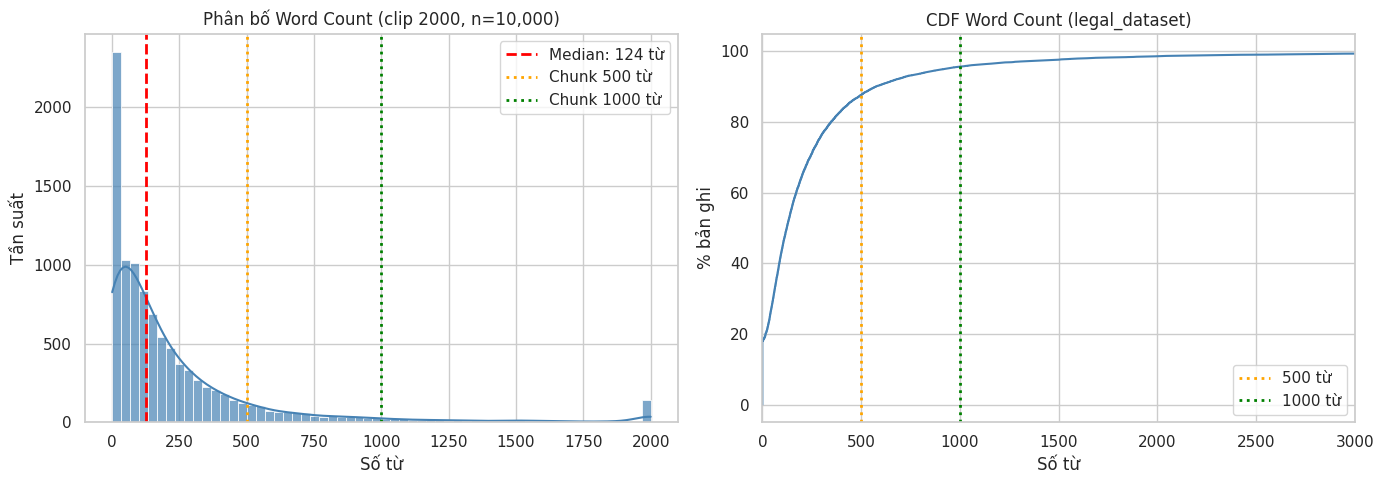

  ≤  200 từ:  64.7% bản ghi
  ≤  500 từ:  87.7% bản ghi
  ≤ 1000 từ:  95.7% bản ghi
  ≤ 2000 từ:  98.6% bản ghi


In [30]:
SAMPLE_SIZE = 10_000

if 'content' in legal_df.columns:
    df_sample = legal_df.sample(min(SAMPLE_SIZE, len(legal_df)), random_state=42)
    df_sample = df_sample.copy()
    df_sample['word_count'] = df_sample['content'].fillna('').astype(str).apply(lambda x: len(x.split()))

    print(f"--- PHÂN TÍCH ĐỘ DÀI VĂN BẢN (mẫu {min(SAMPLE_SIZE, len(legal_df)):,} dòng) ---")
    print(df_sample['word_count'].describe().round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Biểu đồ 1: Distribution
    sns.histplot(df_sample['word_count'].clip(upper=2000), bins=60, kde=True,
                 color='steelblue', alpha=0.7, ax=axes[0])
    axes[0].axvline(df_sample['word_count'].median(), color='red', linestyle='--',
                    linewidth=2, label=f"Median: {df_sample['word_count'].median():.0f} từ")
    axes[0].axvline(500, color='orange', linestyle=':', linewidth=2, label="Chunk 500 từ")
    axes[0].axvline(1000, color='green', linestyle=':', linewidth=2, label="Chunk 1000 từ")
    axes[0].set_title(f'Phân bố Word Count (clip 2000, n={min(SAMPLE_SIZE, len(legal_df)):,})')
    axes[0].set_xlabel('Số từ')
    axes[0].set_ylabel('Tần suất')
    axes[0].legend()

    # Biểu đồ 2: Cumulative distribution
    sorted_wc = df_sample['word_count'].sort_values()
    cdf = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100
    axes[1].plot(sorted_wc.values, cdf, color='steelblue')
    axes[1].axvline(500, color='orange', linestyle=':', linewidth=2, label="500 từ")
    axes[1].axvline(1000, color='green', linestyle=':', linewidth=2, label="1000 từ")
    axes[1].set_xlim(0, 3000)
    axes[1].set_title('CDF Word Count (legal_dataset)')
    axes[1].set_xlabel('Số từ')
    axes[1].set_ylabel('% bản ghi')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Thống kê ngưỡng chunk
    for threshold in [200, 500, 1000, 2000]:
        pct_below = (df_sample['word_count'] <= threshold).mean() * 100
        print(f"  ≤ {threshold:4d} từ: {pct_below:5.1f}% bản ghi")

## 3.8. Mock Retrieval Test — Giả lập truy vấn RAG

In [31]:
def mock_retrieval(df, keyword, num_results=3):
    print(f"\n{'='*60}")
    print(f"TÌM KIẾM: '{keyword}'")
    print('='*60)

    if 'content' not in df.columns:
        print("Không tìm thấy cột 'content'.")
        return

    results = df[df['content'].str.contains(keyword, case=False, na=False)]
    print(f"Tìm thấy {len(results):,} kết quả.\n")

    for idx, (_, row) in enumerate(results.head(num_results).iterrows()):
        content = str(row['content'])
        key_idx = content.lower().find(keyword.lower())
        start_idx = max(0, key_idx - 60)
        end_idx   = min(len(content), key_idx + len(keyword) + 180)
        snippet   = content[start_idx:end_idx].replace('\n', ' ')
        if start_idx > 0: snippet = "..." + snippet
        if end_idx < len(content): snippet += "..."

        print(f"Kết quả {idx+1}:")
        print(f"  📌 {row.get('name', 'N/A')} | {row.get('type', 'N/A')} ({row.get('ministry', 'N/A')})")
        print(f"  📄 {snippet}")
        print()

# Thử 3 từ khoá tiêu biểu
mock_retrieval(legal_df, "nghỉ thai sản")
mock_retrieval(legal_df, "kỷ luật công chức")
mock_retrieval(legal_df, "văn bản hành chính")


TÌM KIẾM: 'nghỉ thai sản'
Tìm thấy 123 kết quả.

Kết quả 1:
  📌 LAO ĐỘNG | LUẬT (QUỐC HỘI)
  📄 ...đồng ý. 3. Người lao động nữ mang thai; người lao động đang nghỉ thai sản hoặc nuôi con dưới 12 tháng tuổi.

Kết quả 2:
  📌 LAO ĐỘNG | LUẬT (QUỐC HỘI)
  📄 ... gian nhất định; b) Thay thế người lao động trong thời gian nghỉ thai sản, bị tai nạn lao động, bệnh nghề nghiệp hoặc phải thực hiện các nghĩa vụ công dân; c) Có nhu cầu sử dụng lao động trình độ chuyên môn, kỹ thuật cao. 3. Bên thuê lại lao động không ...

Kết quả 3:
  📌 LAO ĐỘNG | LUẬT (QUỐC HỘI)
  📄 ...Bộ luật này; d) Người lao động nữ mang thai; người lao động nghỉ thai sản, nuôi con dưới 12 tháng tuổi. 5. Không xử lý kỷ luật lao động đối với người lao động vi phạm kỷ luật lao động trong khi mắc bệnh tâm thần hoặc một bệnh khác làm mất khả năng nhận ...


TÌM KIẾM: 'kỷ luật công chức'
Tìm thấy 107 kết quả.

Kết quả 1:
  📌 TỔ CHỨC QUỐC HỘI | LUẬT (QUỐC HỘI)
  📄 ...hòng Quốc hội trong việc tuyển dụng, bổ nhiệm, khen thưởng, kỷ luật

---
# PHẦN 4 — Tổng kết & Khuyến nghị

In [32]:
print("=" * 70)
print("TỔNG KẾT 3 DATASET")
print("=" * 70)

summary_rows = []

for name, df in [("forms_dataset", forms_df),
                 ("forms_examples_dataset", examples_df),
                 ("legal_dataset", legal_df)]:
    if df is None:
        summary_rows.append({"Dataset": name, "Bản ghi": "N/A", "Cột": "N/A",
                              "Missing (max%)": "N/A", "Ghi chú": "Chưa nạp được"})
        continue

    n_records  = len(df)
    n_cols     = df.shape[1]
    max_miss   = (df.isnull().sum() / len(df) * 100).max()

    notes = []
    if name == "legal_dataset" and 'content' in df.columns:
        dup = df.duplicated(subset=['content']).sum()
        if dup > 0:
            notes.append(f"{dup:,} content trùng")
    if name == "forms_examples_dataset" and 'filled_content' in df.columns:
        bad = df['filled_content'].apply(
            lambda x: len(re.findall(r'\{\{[A-Z_]+\}\}', str(x))) if isinstance(x, str) else 0
        ).gt(0).sum()
        if bad > 0:
            notes.append(f"{bad} ví dụ còn placeholder")
        else:
            notes.append("✅ Tất cả đã điền đầy đủ")

    summary_rows.append({
        "Dataset"       : name,
        "Bản ghi"       : f"{n_records:,}",
        "Cột"           : n_cols,
        "Missing (max%)": f"{max_miss:.1f}%",
        "Ghi chú"       : " | ".join(notes) if notes else "OK"
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_markdown(index=False))

print()
print("KHUYẾN NGHỊ TRƯỚC KHI CHUNKING:")
print("  1. legal_dataset  — De-duplicate theo 'content' (~23.9% có thể trùng).")
print("  2. legal_dataset  — Loại bỏ hoặc impute ~17.6% bản ghi có content = NaN.")
print("  3. legal_dataset  — Chuẩn hoá cột 'type' (nhiều giá trị bị ngắt dòng/nhiễu).")
print("  4. forms_examples — Kiểm tra scenario để đảm bảo đa dạng (không bị bias form).")
print("  5. forms_dataset  — Đủ 10 forms, required_fields đầy đủ — có thể dùng ngay.")

TỔNG KẾT 3 DATASET
| Dataset                |   Bản ghi |   Cột | Missing (max%)   | Ghi chú                  |
|:-----------------------|----------:|------:|:-----------------|:-------------------------|
| forms_dataset          |        10 |    11 | 0.0%             | OK                       |
| forms_examples_dataset |       150 |    91 | 90.0%            | ✅ Tất cả đã điền đầy đủ |
| legal_dataset          |   515,188 |     8 | 17.6%            | 123,108 content trùng    |

KHUYẾN NGHỊ TRƯỚC KHI CHUNKING:
  1. legal_dataset  — De-duplicate theo 'content' (~23.9% có thể trùng).
  2. legal_dataset  — Loại bỏ hoặc impute ~17.6% bản ghi có content = NaN.
  3. legal_dataset  — Chuẩn hoá cột 'type' (nhiều giá trị bị ngắt dòng/nhiễu).
  4. forms_examples — Kiểm tra scenario để đảm bảo đa dạng (không bị bias form).
  5. forms_dataset  — Đủ 10 forms, required_fields đầy đủ — có thể dùng ngay.
